In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import altair as alt
import scipy.stats as stats

In [10]:
def get_permutation(
    ohlc: pd.DataFrame, start_index: int = 0, seed=None
):
    assert start_index >= 0

    np.random.seed(seed)
    n_markets = 1
    time_index = ohlc.index
    ohlc = [ohlc]

    n_bars = len(ohlc[0])

    perm_index = start_index + 1
    perm_n = n_bars - perm_index

    start_bar = np.empty((n_markets, 4))
    relative_open = np.empty((n_markets, perm_n))
    relative_high = np.empty((n_markets, perm_n))
    relative_low = np.empty((n_markets, perm_n))
    relative_close = np.empty((n_markets, perm_n))

    for mkt_i, reg_bars in enumerate(ohlc):
        log_bars = np.log(reg_bars[['open', 'high', 'low', 'close']])

        # Get start bar
        start_bar[mkt_i] = log_bars.iloc[start_index].to_numpy()

        # Open relative to last close
        r_o = (log_bars['open'] - log_bars['close'].shift()).to_numpy()
        
        # Get prices relative to this bars open
        r_h = (log_bars['high'] - log_bars['open']).to_numpy()
        r_l = (log_bars['low'] - log_bars['open']).to_numpy()
        r_c = (log_bars['close'] - log_bars['open']).to_numpy()

        relative_open[mkt_i] = r_o[perm_index:]
        relative_high[mkt_i] = r_h[perm_index:]
        relative_low[mkt_i] = r_l[perm_index:]
        relative_close[mkt_i] = r_c[perm_index:]

    idx = np.arange(perm_n)

    # Shuffle intrabar relative values (high/low/close)
    perm1 = np.random.permutation(idx)
    relative_high = relative_high[:, perm1]
    relative_low = relative_low[:, perm1]
    relative_close = relative_close[:, perm1]

    # Shuffle last close to open (gaps) seprately
    perm2 = np.random.permutation(idx)
    relative_open = relative_open[:, perm2]

    # Create permutation from relative prices
    perm_ohlc = []
    for mkt_i, reg_bars in enumerate(ohlc):
        perm_bars = np.zeros((n_bars, 4))

        # Copy over real data before start index 
        log_bars = np.log(reg_bars[['open', 'high', 'low', 'close']]).to_numpy().copy()
        perm_bars[:start_index] = log_bars[:start_index]
        
        # Copy start bar
        perm_bars[start_index] = start_bar[mkt_i]

        for i in range(perm_index, n_bars):
            k = i - perm_index
            perm_bars[i, 0] = perm_bars[i - 1, 3] + relative_open[mkt_i][k]
            perm_bars[i, 1] = perm_bars[i, 0] + relative_high[mkt_i][k]
            perm_bars[i, 2] = perm_bars[i, 0] + relative_low[mkt_i][k]
            perm_bars[i, 3] = perm_bars[i, 0] + relative_close[mkt_i][k]

        perm_bars = np.exp(perm_bars)
        perm_bars = pd.DataFrame(perm_bars, index=time_index, columns=['open', 'high', 'low', 'close'])

        perm_ohlc.append(perm_bars)

    if n_markets > 1:
        return perm_ohlc
    else:
        return perm_ohlc[0]

0
10
20
30
40
50
60
70
80
90


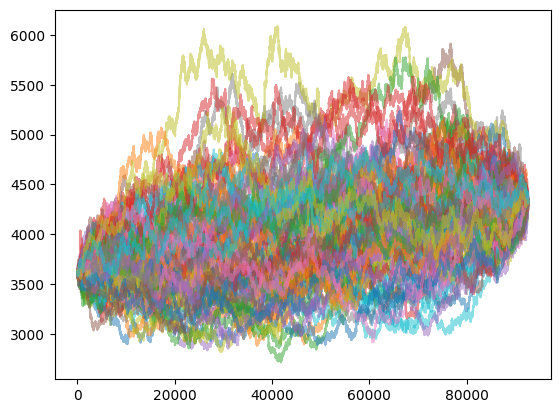

In [ ]:
Britannia=pd.read_csv("ADANIENT_minute.csv")
X=np.linspace(0,len(Britannia),len(Britannia))
for x in range(0,100):
    if x%10==0:
        print(x)
    df=get_permutation(Britannia)
    plt.plot(X,df['close'],alpha=0.5)
plt.show()